In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

# GARCH

In [2]:

bid = pd.read_csv(r"")
ask = pd.read_csv(r"")

In [3]:
df = pd.merge(bid, ask, on="UTC", suffixes=("_bid", "_ask"))
df["UTC"] = pd.to_datetime(df["UTC"], utc=True, dayfirst=True, errors="coerce")
df = df.sort_values("UTC").reset_index(drop=True)

df["mid"] = (df["Close_bid"] + df["Close_ask"]) / 2
df["log_ret"] = np.log(df["mid"]).diff()

h = 30
df["rv_30m"] = df["log_ret"].rolling(h).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True).shift(-h)


In [4]:
df

,UTC,Open_bid,High_bid,Low_bid,Close_bid,Volume_bid,Open_ask,High_ask,Low_ask,Close_ask,Volume_ask,mid,log_ret,rv_30m
0,2025-08-12 14:00:00+00:00,33.906,33.907,33.896,33.897,0.0933,34.084,34.103,33.944,34.083,0.1014,33.990,NaN,0.005420
1,2025-08-12 14:01:00+00:00,33.907,34.017,33.896,34.017,0.1611,34.083,34.133,33.958,34.093,0.1815,34.055,0.001911,0.005105
2,2025-08-12 14:02:00+00:00,33.996,34.026,33.996,34.006,0.0291,34.054,34.064,34.053,34.064,0.0576,34.035,-0.000587,0.005090
3,2025-08-12 14:03:00+00:00,34.036,34.056,33.916,33.917,0.1479,34.064,34.174,34.044,34.053,0.1683,33.985,-0.001470,0.005538
4,2025-08-12 14:04:00+00:00,34.006,34.067,33.917,34.036,0.1191,34.054,34.104,34.053,34.104,0.1806,34.070,0.002498,0.005406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,2025-08-12 19:55:00+00:00,34.167,34.187,34.047,34.127,0.1782,34.203,34.224,34.173,34.173,0.1866,34.150,-0.000878,NaN
341,2025-08-12 19:56:00+00:00,34.127,34.157,34.106,34.157,0.1734,34.163,34.193,34.153,34.173,0.1527,34.165,0.000439,NaN
342,2025-08-12 19:57:00+00:00,34.137,34.147,34.046,34.147,0.1611,34.173,34.174,34.143,34.163,0.1734,34.155,-0.000293,NaN
343,2025-08-12 19:58:00+00:00,34.137,34.157,34.106,34.106,0.2796,34.153,34.193,34.144,34.144,0.2799,34.125,-0.000879,NaN


In [21]:
res.forecast(horizon=h, start=start_idx, align="origin", reindex=True).variance
# garch_next30m_insample
# cond_std_1m_pct 

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10,...,h.21,h.22,h.23,h.24,h.25,h.26,h.27,h.28,h.29,h.30
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.136926e-06,1.055876e-06,9.991405e-07,9.594258e-07,9.316256e-07,9.121654e-07,8.985433e-07,8.890078e-07,8.823330e-07,8.776606e-07,...,8.669739e-07,8.669093e-07,8.668640e-07,8.668323e-07,8.668101e-07,8.667946e-07,8.667837e-07,8.667761e-07,8.667708e-07,8.667671e-07
3,1.267060e-06,1.146970e-06,1.062906e-06,1.004062e-06,9.628708e-07,9.340371e-07,9.138535e-07,8.997249e-07,8.898350e-07,8.829120e-07,...,8.670778e-07,8.669820e-07,8.669149e-07,8.668679e-07,8.668351e-07,8.668120e-07,8.667959e-07,8.667847e-07,8.667768e-07,8.667713e-07
4,2.130900e-06,1.751657e-06,1.486188e-06,1.300359e-06,1.170279e-06,1.079223e-06,1.015483e-06,9.708658e-07,9.396336e-07,9.177710e-07,...,8.677671e-07,8.674644e-07,8.672526e-07,8.671043e-07,8.670006e-07,8.669279e-07,8.668770e-07,8.668414e-07,8.668165e-07,8.667991e-07
5,1.343988e-06,1.200819e-06,1.100601e-06,1.030448e-06,9.813413e-07,9.469664e-07,9.229040e-07,9.060603e-07,8.942697e-07,8.860163e-07,...,8.671392e-07,8.670249e-07,8.669450e-07,8.668890e-07,8.668498e-07,8.668224e-07,8.668032e-07,8.667897e-07,8.667803e-07,8.667737e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,8.917206e-07,8.842320e-07,8.789899e-07,8.753204e-07,8.727518e-07,8.709538e-07,8.696952e-07,8.688141e-07,8.681974e-07,8.677657e-07,...,8.667783e-07,8.667723e-07,8.667681e-07,8.667652e-07,8.667631e-07,8.667617e-07,8.667607e-07,8.667600e-07,8.667595e-07,8.667592e-07
341,7.426054e-07,7.798513e-07,8.059234e-07,8.241739e-07,8.369492e-07,8.458920e-07,8.521519e-07,8.565338e-07,8.596012e-07,8.617483e-07,...,8.666593e-07,8.666890e-07,8.667098e-07,8.667244e-07,8.667346e-07,8.667417e-07,8.667467e-07,8.667502e-07,8.667527e-07,8.667544e-07
342,6.497418e-07,7.148468e-07,7.604203e-07,7.923217e-07,8.146527e-07,8.302844e-07,8.412266e-07,8.488861e-07,8.542478e-07,8.580010e-07,...,8.665852e-07,8.666372e-07,8.666735e-07,8.666990e-07,8.667168e-07,8.667293e-07,8.667380e-07,8.667441e-07,8.667484e-07,8.667514e-07
343,7.431069e-07,7.802023e-07,8.061691e-07,8.243459e-07,8.370696e-07,8.459763e-07,8.522109e-07,8.565751e-07,8.596301e-07,8.617686e-07,...,8.666597e-07,8.666893e-07,8.667100e-07,8.667245e-07,8.667347e-07,8.667418e-07,8.667468e-07,8.667502e-07,8.667527e-07,8.667544e-07


c:\Users\yujie\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 8.668e-07. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
c:\Users\yujie\anaconda3\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


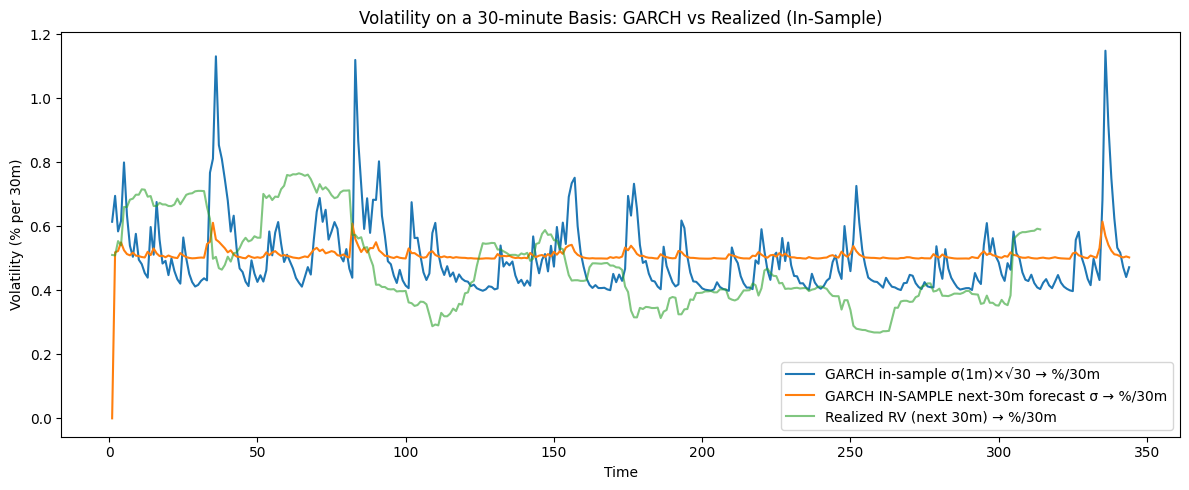

In [ ]:
from arch import arch_model

y = df["log_ret"].dropna()

am = arch_model(y, vol="GARCH", p=1, q=1, mean="Constant", dist="t")
res = am.fit(disp="off")

h = 30
start_idx = y.index[0]

fc = res.forecast(horizon=h, start=start_idx, align="origin", reindex=True)

var_steps_raw = fc.variance
garch_next30m_insample = np.sqrt(var_steps_raw.iloc[:, :h].sum(axis=1)) * 100.0




cond_std_1m_pct = res.conditional_volatility * 100.0
garch_30m_equiv_insample = (cond_std_1m_pct * np.sqrt(30)).reindex(garch_next30m_insample.index)





rv_30m_pct = (df["rv_30m"] * 100.0).reindex(garch_next30m_insample.index)

plt.figure(figsize=(12,5))
plt.plot(garch_30m_equiv_insample, label="GARCH in-sample σ(1m)×√30 → %/30m")
plt.plot(garch_next30m_insample,   label="GARCH IN-SAMPLE next-30m forecast σ → %/30m")
plt.plot(rv_30m_pct, alpha=0.6,    label="Realized RV (next 30m) → %/30m")
plt.title("Volatility on a 30-minute Basis: GARCH vs Realized (In-Sample)")
plt.xlabel("Time"); plt.ylabel("Volatility (% per 30m)")
plt.legend(); plt.tight_layout(); plt.show()


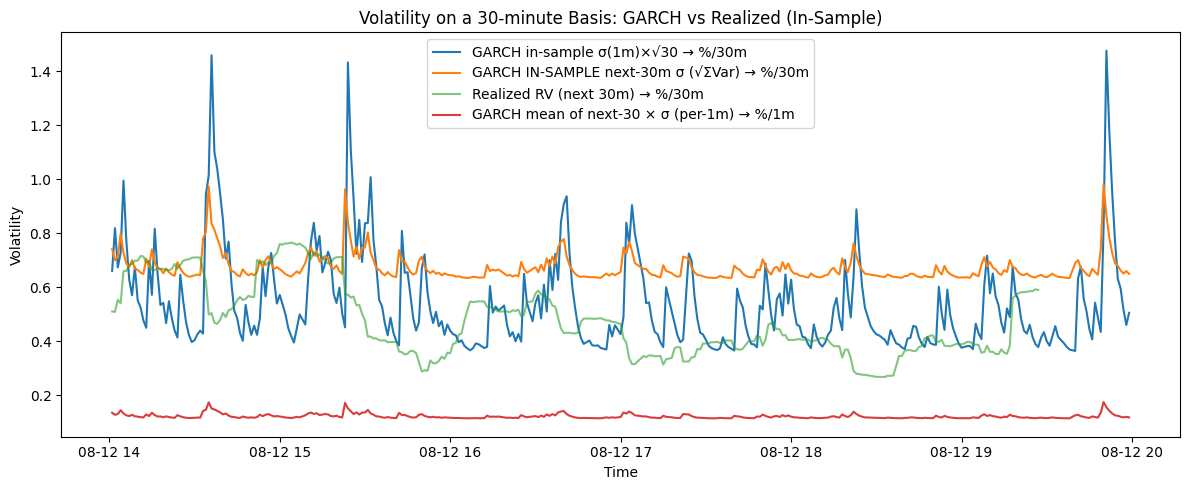

In [124]:
garch_next30m_insample = np.sqrt(var_steps_raw.iloc[:, :h].sum(axis=1)) * 100.0

sigma_steps_1m_pct = np.sqrt(var_steps_raw.iloc[:, :h]) * 100.0
garch_mean_sigma_next30m_1m = sigma_steps_1m_pct.mean(axis=1)

garch_mean_sigma_next30m_30m_equiv = garch_mean_sigma_next30m_1m * np.sqrt(30)

plt.figure(figsize=(12,5))
plt.plot(garch_30m_equiv_insample, label="GARCH in-sample σ(1m)×√30 → %/30m")
plt.plot(garch_next30m_insample,   label="GARCH IN-SAMPLE next-30m σ (√ΣVar) → %/30m")
plt.plot(rv_30m_pct, alpha=0.6,    label="Realized RV (next 30m) → %/30m")
plt.plot(garch_mean_sigma_next30m_1m, label="GARCH mean of next-30 × σ (per-1m) → %/1m", alpha=0.9)
# plt.plot(garch_mean_sigma_next30m_30m_equiv, label="GARCH mean σ × √30 (heuristic) → %/30m", alpha=0.9)

plt.title("Volatility on a 30-minute Basis: GARCH vs Realized (In-Sample)")
plt.xlabel("Time"); plt.ylabel("Volatility")
plt.legend(); plt.tight_layout(); plt.show()


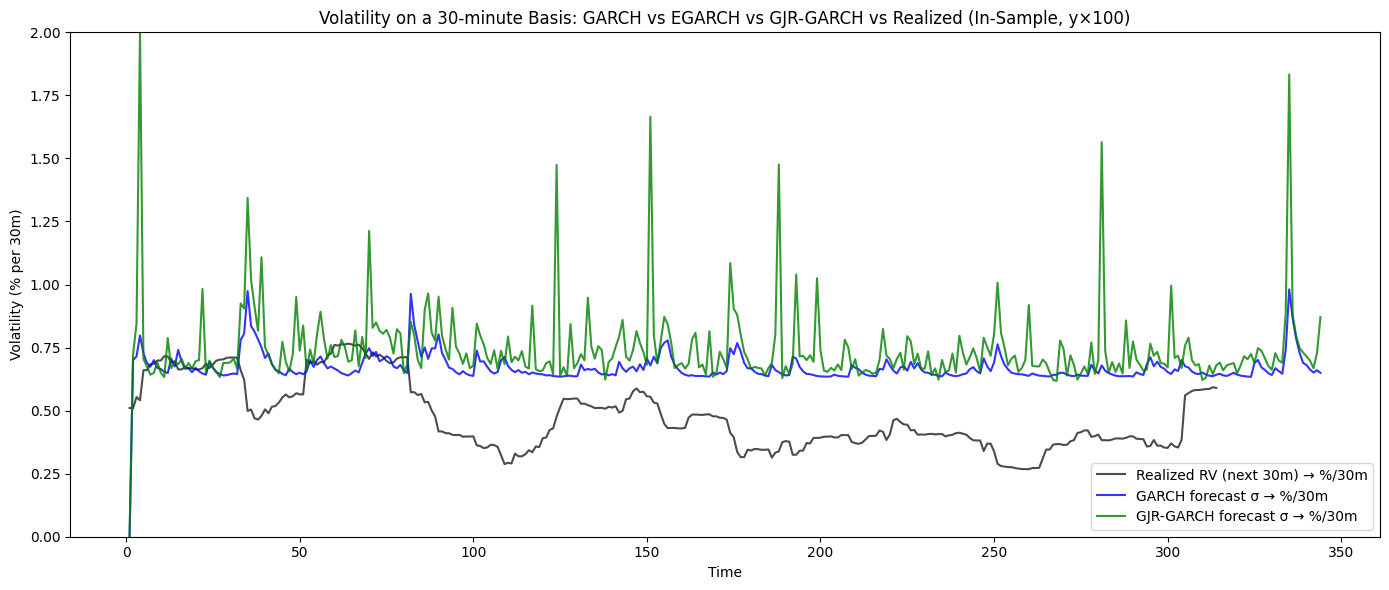

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model


y = df["log_ret"].dropna()
y_scaled = y * 100 

h = 30
start_idx = y_scaled.index[0]

am_garch = arch_model(y_scaled, vol="GARCH", p=1, q=1, mean="Constant", dist="t", rescale=False)
res_garch = am_garch.fit(disp="off")

fc_garch = res_garch.forecast(horizon=h, start=start_idx, align="origin", reindex=True)
var_steps_garch = fc_garch.variance
garch_next30m = np.sqrt(var_steps_garch.iloc[:, :h].sum(axis=1))

am_egarch = arch_model(y_scaled, vol="EGARCH", p=1, q=1, mean="Constant", dist="t", rescale=False)
res_egarch = am_egarch.fit(disp="off")

fc_egarch = res_egarch.forecast(horizon=h, start=start_idx, align="origin",
                                reindex=True, method="simulation", simulations=2000, random_state=42)
var_steps_egarch = fc_egarch.variance
egarch_next30m = np.sqrt(var_steps_egarch.iloc[:, :h].sum(axis=1))

am_gjr = arch_model(y_scaled, vol="GARCH", p=1, o=1, q=1, mean="Constant", dist="t", rescale=False)
res_gjr = am_gjr.fit(disp="off")

fc_gjr = res_gjr.forecast(horizon=h, start=start_idx, align="origin",
                          reindex=True, method="simulation", simulations=2000, random_state=42)
var_steps_gjr = fc_gjr.variance
gjr_next30m = np.sqrt(var_steps_gjr.iloc[:, :h].sum(axis=1))

rv_30m = df["rv_30m"].reindex(garch_next30m.index)*100

plt.figure(figsize=(14,6))
plt.plot(rv_30m, alpha=0.7, label="Realized RV (next 30m) → %/30m", color="black")
plt.plot(garch_next30m, label="GARCH forecast σ → %/30m", color="blue", alpha=0.8)
# plt.plot(egarch_next30m, label="EGARCH forecast σ → %/30m", color="red", alpha=0.8)
plt.plot(gjr_next30m, label="GJR-GARCH forecast σ → %/30m", color="green", alpha=0.8)

plt.title("Volatility on a 30-minute Basis: GARCH vs EGARCH vs GJR-GARCH vs Realized (In-Sample, y×100)")
plt.xlabel("Time")
plt.ylabel("Volatility (% per 30m)")

plt.ylim(0, 2)  

plt.legend()
plt.tight_layout()
plt.show()


1. intra-day shock VS low-freq model
2. gjr's capture of asymetry is useless

# GCN

In [31]:
apa_ask = pd.read_csv("APA.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_ask.csv")
apa_bid = pd.read_csv("APA.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_bid.csv")

eqt_ask = pd.read_csv("EQT.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_ask.csv")
eqt_bid = pd.read_csv("EQT.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_bid.csv")

ar_ask = pd.read_csv("AR.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_ask.csv")
ar_bid = pd.read_csv("AR.US-USD_Minute_2025-08-12_to_2025-08-29_UTC_bid.csv")

rrc_ask = pd.read_csv("RRC.US-USD_Minute_2025-08-12_to_2025-08-28_UTC_ask.csv")
rrc_bid = pd.read_csv("RRC.US-USD_Minute_2025-08-12_to_2025-08-28_UTC_bid.csv")


In [32]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prep_ticker(bid_df, ask_df):
    bid = bid_df.copy()
    ask = ask_df.copy()
    bid["UTC"] = pd.to_datetime(bid["UTC"], utc=True, errors="coerce")
    ask["UTC"] = pd.to_datetime(ask["UTC"], utc=True, errors="coerce")
    bid = bid.sort_values("UTC")
    ask = ask.sort_values("UTC")
    df = pd.merge_asof(bid, ask, on="UTC", suffixes=("_bid", "_ask"))
    df = df.set_index("UTC").sort_index()
    for col in ["Open", "High", "Low", "Close"]:
        df[f"{col}_mid"] = 0.5 * (df[f"{col}_bid"] + df[f"{col}_ask"])
    df["spread"] = df["Close_ask"] - df["Close_bid"]
    df["vol_bid"] = df["Volume_bid"]
    df["vol_ask"] = df["Volume_ask"]
    df["vol_tot"] = df["vol_bid"] + df["vol_ask"]
    df["log_ret"] = np.log(df["Close_mid"]).diff()
    df["rv_past30"] = df["log_ret"].pow(2).rolling(window=30, min_periods=30).sum().pow(0.5)
    df["rv_next30_var"] = df["log_ret"].pow(2).rolling(window=30, min_periods=30).sum().shift(-30)
    df["rv_next30_vol_pct"] = df["rv_next30_var"].pow(0.5) * 100.0
    keep = [
        "Open_mid","High_mid","Low_mid","Close_mid",
        "spread","vol_bid","vol_ask","vol_tot",
        "log_ret","rv_past30","rv_next30_var","rv_next30_vol_pct"
    ]
    return df[keep]

apa = prep_ticker(apa_bid, apa_ask)
eqt = prep_ticker(eqt_bid, eqt_ask)
ar  = prep_ticker(ar_bid,  ar_ask)
rrc = prep_ticker(rrc_bid, rrc_ask)


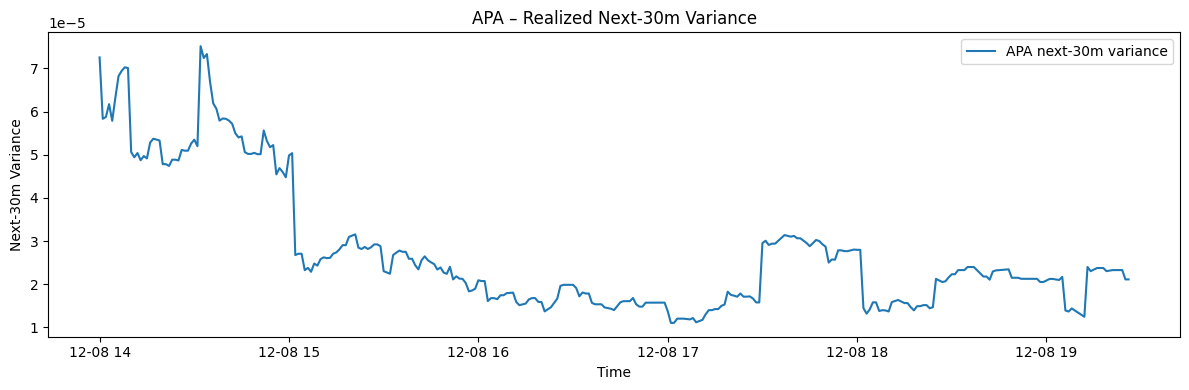

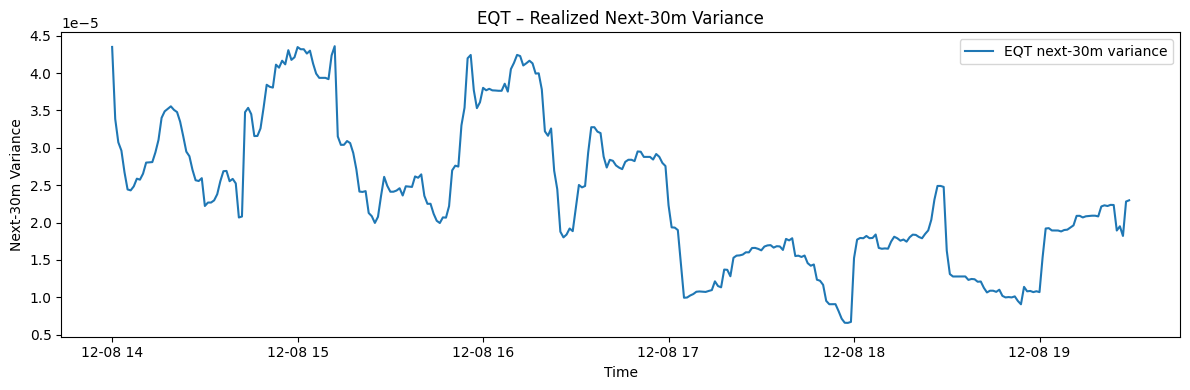

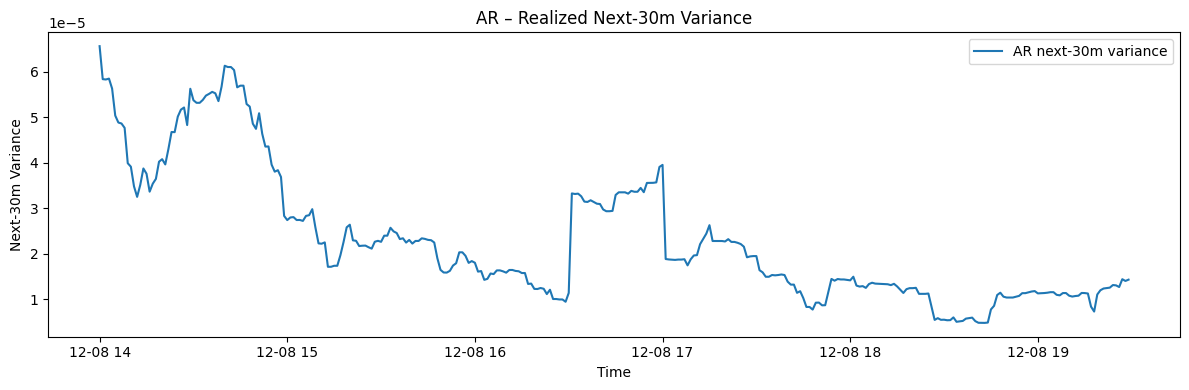

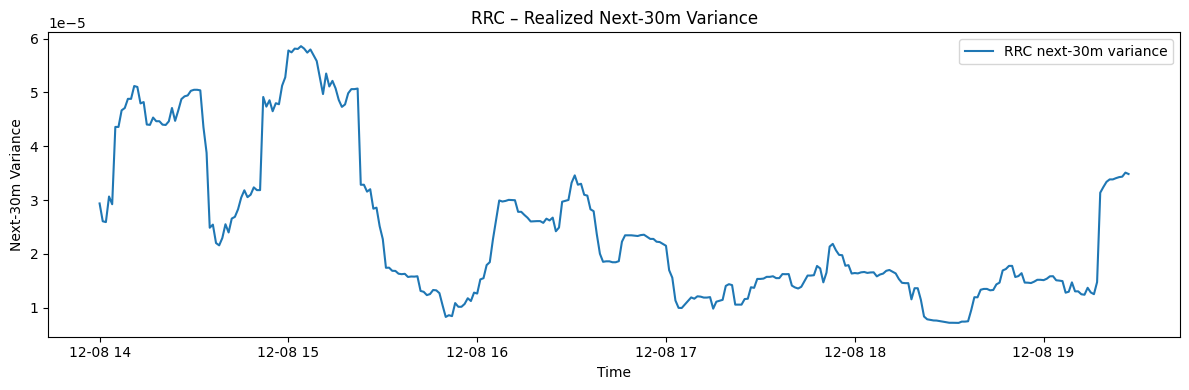

In [45]:
tickers_df = {
    "APA": apa,
    "EQT": eqt,
    "AR": ar,
    "RRC": rrc
}

for name, df in tickers_df.items():
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["rv_next30_var"], label=f"{name} next-30m variance")
    plt.xlabel("Time")
    plt.ylabel("Next-30m Variance")
    plt.title(f"{name} – Realized Next-30m Variance")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [48]:
pan.head()

APA                                             \
                          Open_mid High_mid  Low_mid Close_mid spread vol_bid   
UTC                                                                             
2025-12-08 14:30:00+00:00   20.355  20.3600  20.3050    20.345  0.016  0.7275   
2025-12-08 14:31:00+00:00   20.340  20.3455  20.3195    20.320  0.028  0.1584   
2025-12-08 14:32:00+00:00   20.315  20.3205  20.2995    20.300  0.026  0.2634   
2025-12-08 14:33:00+00:00   20.305  20.3150  20.2645    20.265  0.016  0.4185   
2025-12-08 14:34:00+00:00   20.270  20.2805  20.2495    20.260  0.028  0.3690   

                                                               ...      RRC  \
                          vol_ask vol_tot   log_ret rv_past30  ...  Low_mid   
UTC                                                            ...            
2025-12-08 14:30:00+00:00  0.7725  1.5000 -0.000246  0.008517  ...  34.2395   
2025-12-08 14:31:00+00:00  0.1215  0.2799 -0.001230  0.007637  ...  34.2250   
2025-12-08 14:32:00+00:00  0.2757  0.5391 -0.000985  0.007664  ...  34.2095   
2025-12-08 14:33:00+00:00  0.4104  0.8289 -0.001726  0.007856  ...  34.1800   
2025-12-08 14:34:00+00:00  0.3648  0.7338 -0.000247  0.007606  ...  34.1745   

                                                                              \
                          Close_mid spread vol_bid vol_ask vol_tot   log_ret   
UTC                                                                            
2025-12-08 14:30:00+00:00    34.305  0.138  0.2280  0.2361  0.4641  0.000583   
2025-12-08 14:31:00+00:00    34.285  0.176  0.1419  0.1419  0.2838 -0.000583   
2025-12-08 14:32:00+00:00    34.270  0.148  0.1056  0.0687  0.1743 -0.000438   
2025-12-08 14:33:00+00:00    34.180  0.048  0.2070  0.1578  0.3648 -0.002630   
2025-12-08 14:34:00+00:00    34.255  0.136  0.1602  0.1806  0.3408  0.002192   

                                                                     
                          rv_past30 rv_next30_var rv_next30_vol_pct  
UTC                                                                  
2025-12-08 14:30:00+00:00  0.005420      0.000051          0.710658  
2025-12-08 14:31:00+00:00  0.005105      0.000051          0.710668  
2025-12-08 14:32:00+00:00  0.005090      0.000050          0.709922  
2025-12-08 14:33:00+00:00  0.005538      0.000044          0.660070  
2025-12-08 14:34:00+00:00  0.005406      0.000039          0.622787  

[5 rows x 48 columns]

In [49]:
pan.loc[:, pd.IndexSlice[:, "rv_next30_vol_pct"]]

,APA,EQT,AR,RRC
,rv_next30_vol_pct,rv_next30_vol_pct,rv_next30_vol_pct,rv_next30_vol_pct
UTC,,,,
2025-12-08 14:30:00+00:00,0.731328,0.471335,0.733422,0.710658
2025-12-08 14:31:00+00:00,0.720918,0.476192,0.729494,0.710668
2025-12-08 14:32:00+00:00,0.866823,0.476192,0.729493,0.709922
2025-12-08 14:33:00+00:00,0.850886,0.479251,0.733861,0.660070
2025-12-08 14:34:00+00:00,0.856168,0.487762,0.740290,0.622787
...,...,...,...,...
2025-12-08 19:21:00+00:00,0.482440,0.472271,0.352335,0.581774
2025-12-08 19:23:00+00:00,0.482447,0.472903,0.355032,0.583760


In [60]:
# np.stack([target_vol[tk].values for tk in tickers], axis=1)

In [52]:
np.shape(panel_to_tensor(pan, feat_cols, tickers))

(250, 4, 4)

In [63]:
np.shape(np.stack([target_vol[tk].values for tk in tickers], axis=1))

(250, 4, 1)

In [54]:
np.shape(np.stack([target_var[tk].values for tk in tickers], axis=1))

(250, 4, 1)

In [ ]:
pan = pd.concat(
    {"APA": apa, "EQT": eqt, "AR": ar, "RRC": rrc},
    axis=1, join="inner"
).sort_index()

pan = pan.dropna()

tickers = ["APA","EQT","AR","RRC"]
N = len(tickers)

feat_cols = ["log_ret", "rv_past30", "spread", "vol_tot"]
F = len(feat_cols)

target_vol = pan.loc[:, pd.IndexSlice[:, "rv_next30_vol_pct"]].copy()
target_var = pan.loc[:, pd.IndexSlice[:, "rv_next30_var"]].copy()

def panel_to_tensor(pan, feat_cols, tickers):
    X_list = []
    for tk in tickers:
        X_list.append(pan[tk][feat_cols].values)
    X = np.stack(X_list, axis=1)
    return X # (T,N,K) = (250, 4, 4)

X_np = panel_to_tensor(pan, feat_cols, tickers)
y_vol_np = np.stack([target_vol[tk].values for tk in tickers], axis=1) # (250, 4, 1)

y_var_np = np.stack([target_var[tk].values for tk in tickers], axis=1) # (250, 4, 1)

T = X_np.shape[0]
index_time = pan.index


On above is the standard input of GCN

In [58]:
np.shape(X_train_flat)

(800, 4)

In [ ]:
train_ratio = 0.8
T_train = int(T * train_ratio)

# chronical split to avoid future looking
X_train_np, X_val_np = X_np[:T_train], X_np[T_train:]
y_vol_train_np, y_vol_val_np = y_vol_np[:T_train], y_vol_np[T_train:] # (250*0.8, 4, 1)
y_var_train_np, y_var_val_np = y_var_np[:T_train], y_var_np[T_train:]

# flatten because of scalar
scaler = StandardScaler()
X_train_flat = X_train_np.reshape(-1, F) # (T_tr,N,F) -> (T_tr*N,F)
scaler.fit(X_train_flat) # miu_j & sigma_j
X_train_np = scaler.transform(X_train_flat).reshape(-1, N, F)  # standardized # (T_tr*N,F) -> (T_tr,N,F)
X_val_np   = scaler.transform(X_val_np.reshape(-1, F)).reshape(-1, N, F)

use_log_target = False
if use_log_target:
    y_train_np = np.log1p(y_vol_train_np) # log(1+x)
    y_val_np   = np.log1p(y_vol_val_np)
else:
    y_train_np = y_vol_train_np
    y_val_np   = y_vol_val_np


In [79]:
# rets_train_df
# corr
A

array([[1.        , 0.13344611, 0.41495159, 0.35709021],
       [0.13344611, 1.        , 0.36881255, 0.43425769],
       [0.41495159, 0.36881255, 1.        , 0.44733187],
       [0.35709021, 0.43425769, 0.44733187, 1.        ]])

In [78]:
tickers = ["APA","EQT","AR","RRC"]
N = len(tickers)

T_train = int(T * train_ratio)
idx_train = index_time[:T_train]

rets_train_df = pd.concat(
    [pan.loc[idx_train, (tk, "log_ret")].rename(tk) for tk in tickers],
    axis=1
)

corr = rets_train_df.corr().values # N*N
A = np.abs(corr)
np.fill_diagonal(A, 1.0)
A[A < 0.1] = 0.0

A_tilde = A + np.eye(N)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A_tilde.sum(axis=1) + 1e-8))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

A_hat_t = torch.tensor(A_hat, dtype=torch.float32, device=device)


In [37]:
seq_len = 30

def build_sequences(X, y, seq_len):
    X_seq = []
    y_seq = []
    for t in range(seq_len-1, len(X)):
        X_seq.append(X[t-seq_len+1:t+1])
        y_seq.append(y[t])
    return np.array(X_seq), np.array(y_seq)

Xtr, ytr = build_sequences(X_train_np, y_train_np, seq_len)
Xva, yva = build_sequences(X_val_np,   y_val_np,   seq_len)

Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).squeeze(-1)
Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
yva_t = torch.tensor(yva, dtype=torch.float32, device=device).squeeze(-1)


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, X, A_hat):
        if X.dim() == 1:
            X = X.view(1, 1, -1, 1)
        elif X.dim() == 2:
            X = X.unsqueeze(0).unsqueeze(0)
        elif X.dim() == 3:
            X = X.unsqueeze(0)
        elif X.dim() != 4:
            raise RuntimeError(f"Unexpected X dim {X.dim()} with shape {tuple(X.shape)}")

        if A_hat.dim() != 2:
            raise RuntimeError(f"A_hat must be 2D [N,N], got {tuple(A_hat.shape)}")

        Xg = torch.einsum('nm,blmf->blnf', A_hat, X)
        out = self.lin(Xg)
        return torch.relu(out)


class GCN_LSTM(nn.Module):
    def __init__(self, in_features, gcn_hidden, lstm_hidden, lstm_layers=1, dropout=0.0):
        super().__init__()
        self.gcn1 = GCNLayer(in_features, gcn_hidden)
        self.dropout = nn.Dropout(dropout)
        self.lstm_hidden = lstm_hidden
        self.lstm_layers = lstm_layers
        self.lstm = nn.LSTM(
            input_size=gcn_hidden,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True
        )
        self.head = nn.Linear(lstm_hidden, 1)

    def forward(self, X, A_hat):
        H = self.gcn1(X, A_hat)
        H = self.dropout(H)

        B, L, N, Hf = H.shape
        H2 = H.permute(0,2,1,3).contiguous().view(B*N, L, Hf)
        out, _ = self.lstm(H2)
        last = out[:, -1, :]
        yhat = self.head(last).view(B, N)
        return yhat


gcn_hidden = 32
lstm_hidden = 64
lstm_layers = 1
dropout = 0.1
lr = 1e-3
weight_decay = 1e-5
epochs = 30
batch_size = 256

model = GCN_LSTM(F, gcn_hidden, lstm_hidden, lstm_layers, dropout).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

def batch_iter(X, y, bs):
    n = X.shape[0]
    idx = np.arange(n)
    np.random.shuffle(idx)
    for i in range(0, n, bs):
        j = idx[i:i+bs]
        yield X[j], y[j]


In [38]:
best_val = float("inf")
best_state = None

for ep in range(1, epochs+1):
    model.train()
    tr_losses = []
    for xb, yb in batch_iter(Xtr_t, ytr_t, batch_size):
        opt.zero_grad()
        yhat = model(xb, A_hat_t)
        loss = loss_fn(yhat, yb)
        loss.backward()
        opt.step()
        tr_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        yhat_val = model(Xva_t, A_hat_t)
        val_loss = loss_fn(yhat_val, yva_t).item()

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})


[APA] Vol: MSE=0.004863, R^2=-1.2677
[EQT] Vol: MSE=0.000845, R^2=0.4151
[AR] Vol: MSE=0.017460, R^2=-39.1140
[RRC] Vol: MSE=0.014096, R^2=-0.4605


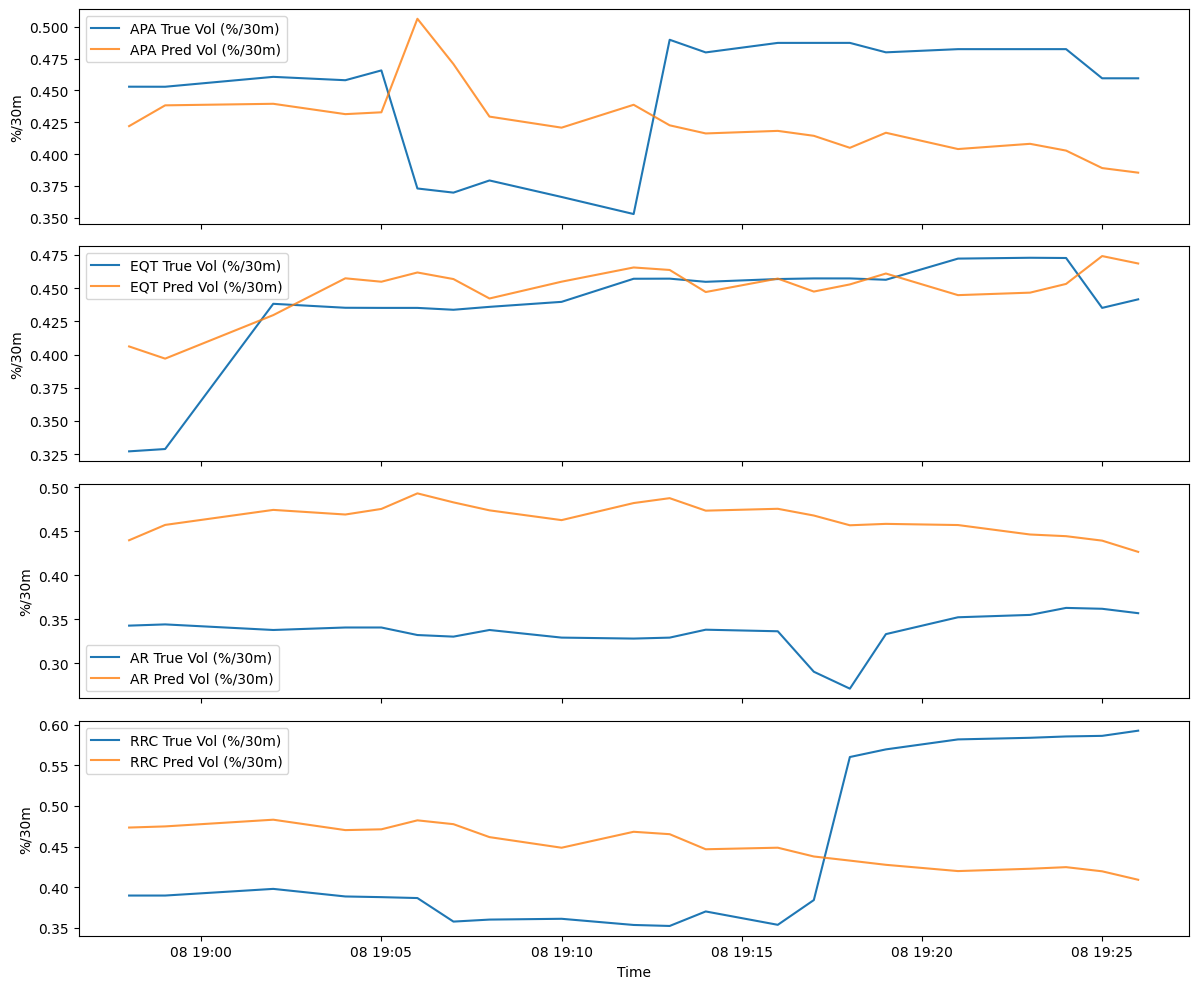

In [39]:

model.eval()
with torch.no_grad():
    yhat_val = model(Xva_t, A_hat_t).cpu().numpy()

if use_log_target:
    yhat_vol = np.expm1(yhat_val)
    y_true_vol = y_vol_val_np[seq_len-1:]
else:
    yhat_vol = yhat_val
    y_true_vol = y_vol_val_np[seq_len-1:]

yhat_var = (yhat_vol / 100.0) ** 2 * 1.0
y_true_var = y_var_val_np[seq_len-1:]

def metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
    r2  = r2_score(y_true.flatten(), y_pred.flatten())
    print(f"{label}: MSE={mse:.6f}, R^2={r2:.4f}")

fig, axes = plt.subplots(N, 1, figsize=(12, 2.5*N), sharex=True)
tv = pd.Index(index_time[T_train + seq_len - 1:])

for i, tk in enumerate(tickers):
    ax = axes[i] if N > 1 else axes
    ax.plot(tv, y_true_vol[:, i], label=f"{tk} True Vol (%/30m)")
    ax.plot(tv, yhat_vol[:, i], label=f"{tk} Pred Vol (%/30m)", alpha=0.8)
    ax.set_ylabel("%/30m")
    ax.legend()
    metrics(y_true_vol[:, i], yhat_vol[:, i], f"[{tk}] Vol")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


# Comparaison

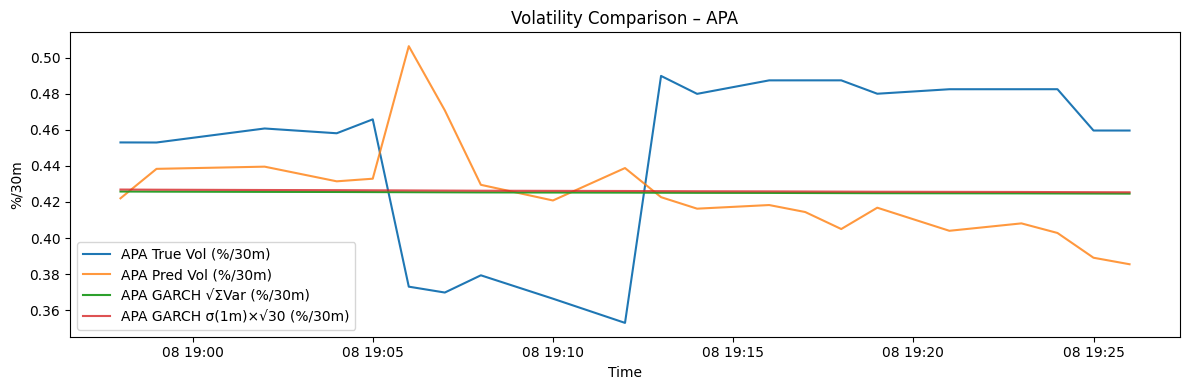

[APA] Vol GCN+LSTM: MSE=0.004863, R^2=-1.2677
[APA] Vol GARCH √ΣVar: MSE=0.002684, R^2=-0.2516
[APA] Vol GARCH σ(1m)×√30: MSE=0.002647, R^2=-0.2344
--------------------------------------------------


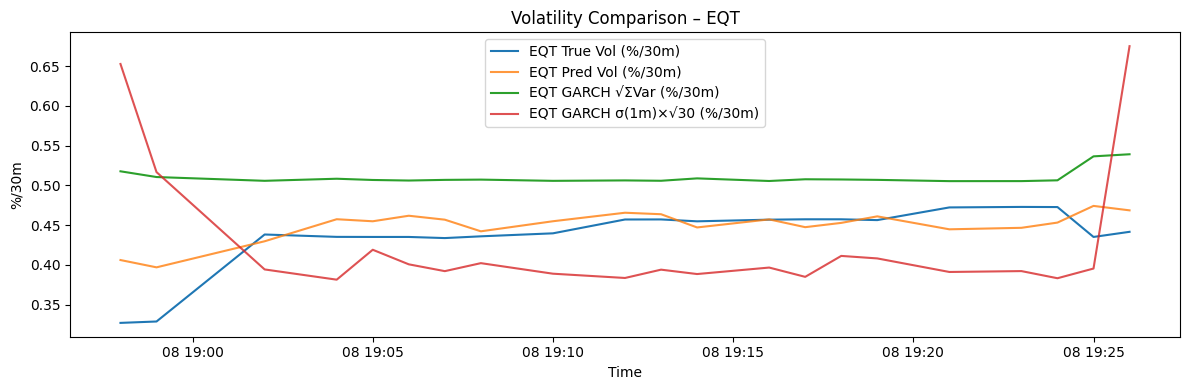

[EQT] Vol GCN+LSTM: MSE=0.000845, R^2=0.4151
[EQT] Vol GARCH √ΣVar: MSE=0.006903, R^2=-3.7755
[EQT] Vol GARCH σ(1m)×√30: MSE=0.012256, R^2=-7.4786
--------------------------------------------------


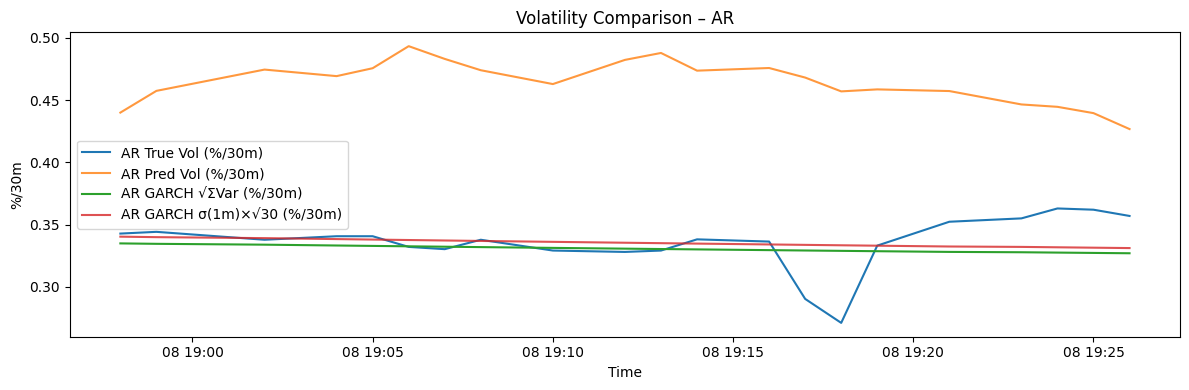

[AR] Vol GCN+LSTM: MSE=0.017460, R^2=-39.1140
[AR] Vol GARCH √ΣVar: MSE=0.000476, R^2=-0.0946
[AR] Vol GARCH σ(1m)×√30: MSE=0.000453, R^2=-0.0417
--------------------------------------------------


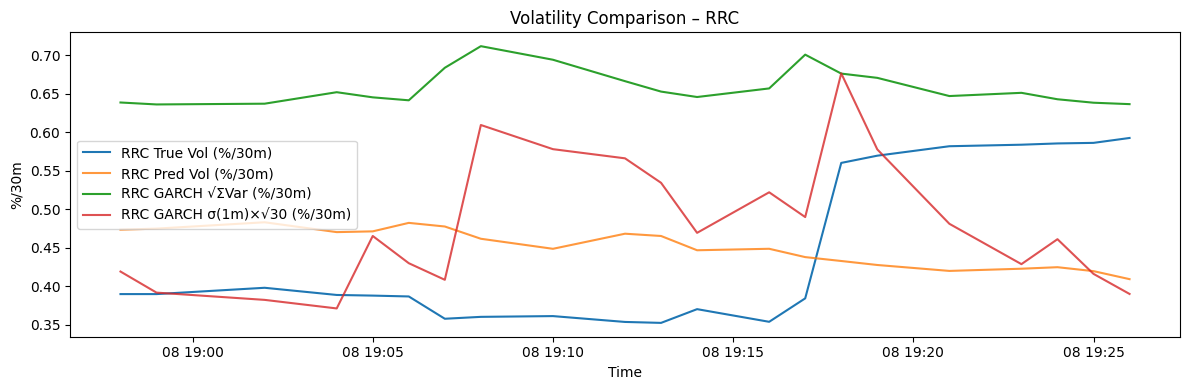

[RRC] Vol GCN+LSTM: MSE=0.014096, R^2=-0.4605
[RRC] Vol GARCH √ΣVar: MSE=0.058005, R^2=-5.0099
[RRC] Vol GARCH σ(1m)×√30: MSE=0.018187, R^2=-0.8844
--------------------------------------------------


In [40]:
from arch import arch_model

def garch_insample_series(df_one_ticker, scale_y=1000.0, h=30):
    ret_1m_raw = df_one_ticker["log_ret"].dropna()
    y = ret_1m_raw * scale_y

    am  = arch_model(y, vol="GARCH", p=1, q=1, mean="Constant", dist="t")
    res = am.fit(disp="off")

    start_idx = ret_1m_raw.index[0]
    fc = res.forecast(horizon=h, start=start_idx, align="origin", reindex=True)

    var_steps_raw = fc.variance / (scale_y**2)
    garch_next30m_insample = np.sqrt(var_steps_raw.iloc[:, :h].sum(axis=1)) * 100.0

    cond_std_1m_pct = (res.conditional_volatility / scale_y) * 100.0
    garch_30m_equiv_insample = (cond_std_1m_pct * np.sqrt(30)).reindex(garch_next30m_insample.index)

    return garch_next30m_insample, garch_30m_equiv_insample

per_ticker_df = {"APA": apa, "EQT": eqt, "AR": ar, "RRC": rrc}

garch_next30_val = {}
garch_equiv30_val = {}
for tk in tickers:
    g_next30, g_equiv30 = garch_insample_series(per_ticker_df[tk])
    g_next30 = g_next30.reindex(index_time).reindex(tv)
    g_equiv30 = g_equiv30.reindex(index_time).reindex(tv)
    garch_next30_val[tk] = g_next30.values
    garch_equiv30_val[tk] = g_equiv30.values

tv = pd.Index(index_time[T_train + seq_len - 1:])

for i, tk in enumerate(tickers):
    plt.figure(figsize=(12, 4))
    plt.plot(tv, y_true_vol[:, i], label=f"{tk} True Vol (%/30m)")
    plt.plot(tv, yhat_vol[:, i],  label=f"{tk} Pred Vol (%/30m)", alpha=0.8)
    plt.plot(tv, garch_next30_val[tk], label=f"{tk} GARCH √ΣVar (%/30m)")
    plt.plot(tv, garch_equiv30_val[tk], label=f"{tk} GARCH σ(1m)×√30 (%/30m)", alpha=0.8)
    plt.ylabel("%/30m")
    plt.xlabel("Time")
    plt.title(f"Volatility Comparison – {tk}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    metrics(y_true_vol[:, i], yhat_vol[:, i], f"[{tk}] Vol GCN+LSTM")
    metrics(y_true_vol[:, i], garch_next30_val[tk], f"[{tk}] Vol GARCH √ΣVar")
    metrics(y_true_vol[:, i], garch_equiv30_val[tk], f"[{tk}] Vol GARCH σ(1m)×√30")
    print("-" * 50)



